In [ ]:
!uv pip install --system "git+https://github.com/Armandpl/ai_image_models.git"

In [1]:
import torch
import matplotlib.pyplot as plt

from ai_image_models.data import PixelArtDataset
from ai_image_models.models import FlowMLP
from ai_image_models.learner import Learner, train_classifier

In [2]:
ds = PixelArtDataset()
clf = train_classifier(ds)

flow = FlowMLP(img_shape=(16, 16, 3))
flow.load_state_dict(torch.load("../01_train/flow_mlp.pt", map_location="cpu", weights_only=True))
learner = Learner(flow)

epoch 04 | acc 1.0000: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:11<00:00,  2.26s/it]


In [3]:
real = clf.features(ds.x[:2048])

def fid(f1, f2):
    m1, m2 = f1.mean(0), f2.mean(0)
    c1, c2 = torch.cov(f1.T), torch.cov(f2.T)
    eig = torch.linalg.eigvals(c1 @ c2).real.clamp(min=0)
    return (((m1 - m2) ** 2).sum() + torch.trace(c1 + c2) - 2 * eig.sqrt().sum()).item()

steps   1 | fid 297.613
steps   2 | fid 144.145
steps   3 | fid 89.621
steps   4 | fid 62.464
steps   5 | fid 43.849
steps   6 | fid 44.133
steps   7 | fid 29.399
steps   8 | fid 30.624
steps   9 | fid 27.636
steps  10 | fid 26.772
steps  50 | fid 15.721
steps 100 | fid 10.924
steps 300 | fid 14.891


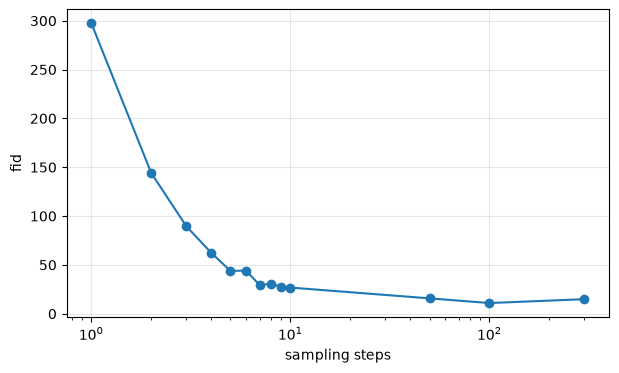

In [4]:
step_counts = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 50, 100, 300]
fids = []
for steps in step_counts:
    gen = clf.features(learner.generate(n=2048, steps=steps))
    fids.append(fid(real, gen))
    print(f"steps {steps:>3} | fid {fids[-1]:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(step_counts, fids, marker="o")
plt.xscale("log")
plt.xlabel("sampling steps")
plt.ylabel("fid")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
fig, axes = plt.subplots(8, len(step_counts), figsize=(len(step_counts), 8))
for j, steps in enumerate(step_counts):
    imgs = learner.generate(n=8, steps=steps)
    for i in range(8):
        axes[i, j].imshow(imgs[i].numpy())
        axes[i, j].axis("off")
    axes[0, j].set_title(str(steps))
plt.show()